In [1]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv('./diabetes.csv')
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [3]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


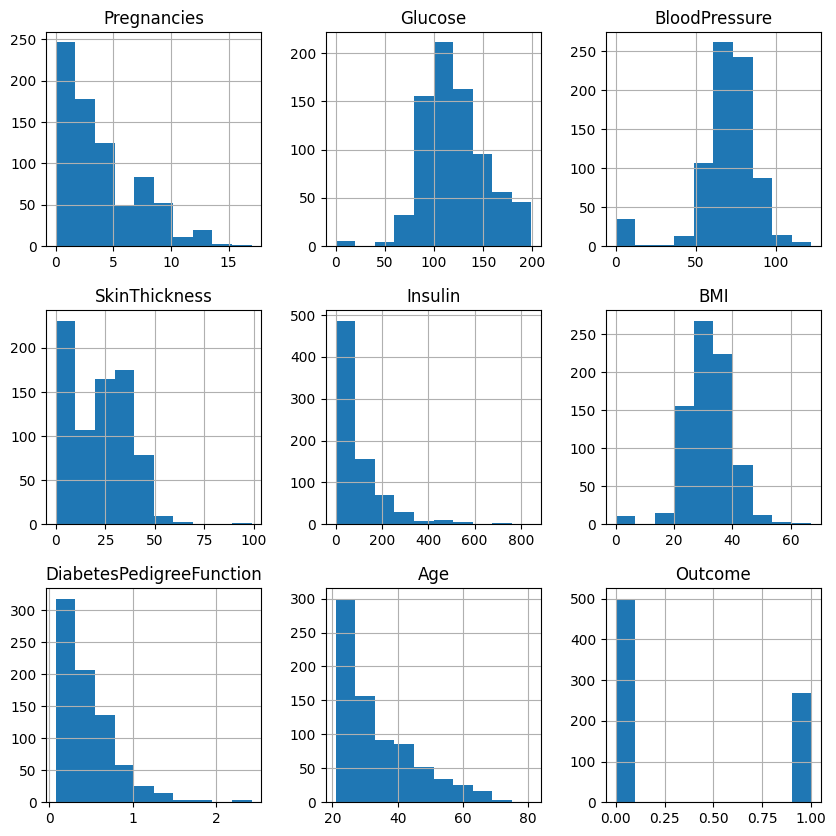

In [5]:
# draw histogram
df.hist(figsize=(10, 10))
plt.show()

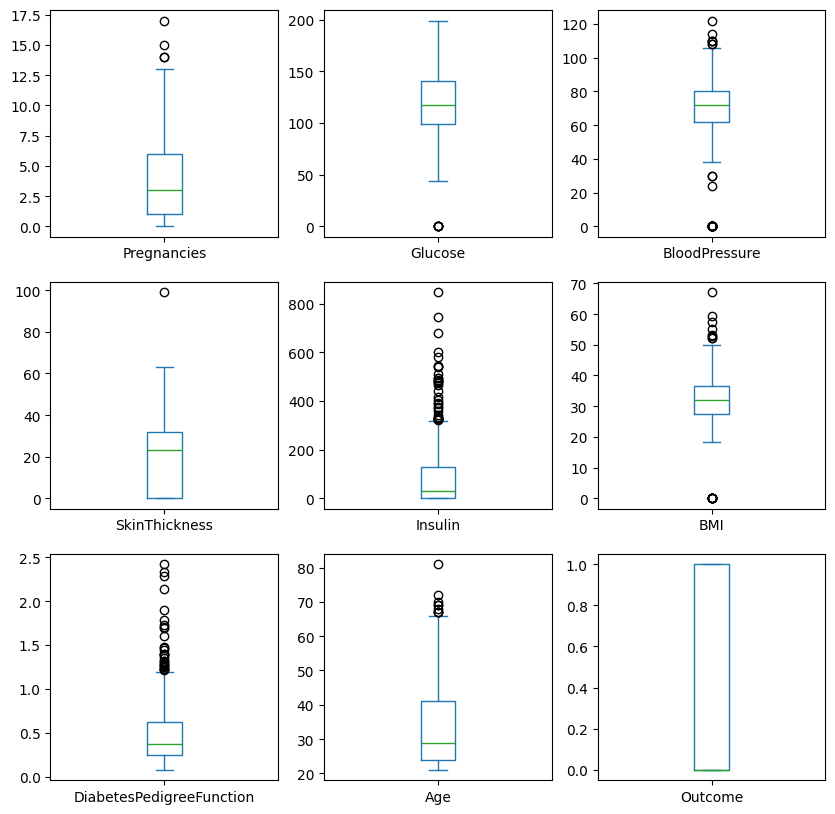

In [6]:
# draw boxplot
df.plot(
    kind='box',
    subplots=True,
    layout=(-1, 3),
    figsize=(10,10)
)
plt.show()

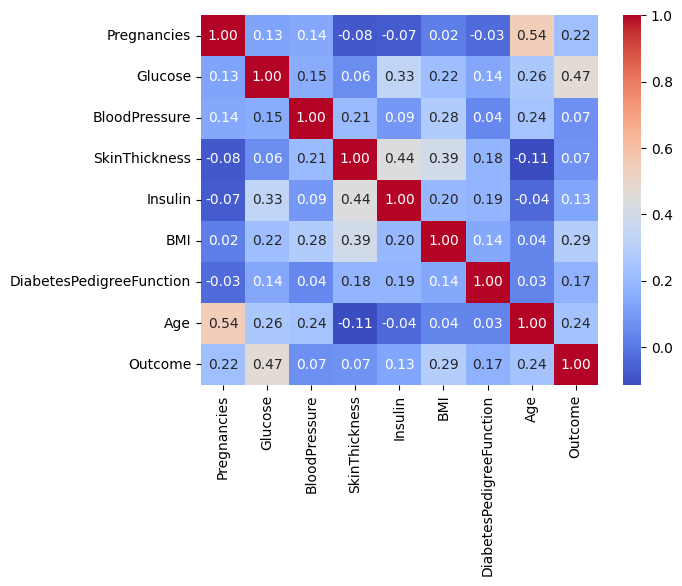

In [7]:
# draw Correlation Heatmap
corr = df.corr()

sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.show()

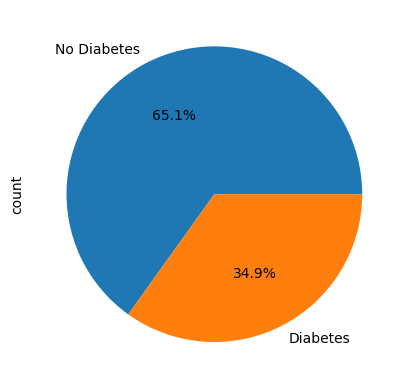

In [ ]:
df['Outcome'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No Diabetes', 'Diabetes'],
)

plt.show()

# **Data cleaning**



### **1. Missing values**

In [9]:
# missing value
count_zero_Glucose = (df['Glucose'] == 0).sum()
count_zero_BloodPressure = (df['BloodPressure'] == 0).sum()
count_zero_SkinThickness = (df['SkinThickness'] == 0).sum()
count_zero_Insulin = (df['Insulin'] == 0).sum()
count_zero_BMI = (df['BMI'] == 0).sum()

print(f"Count of missing values in Glucose: {count_zero_Glucose} ({count_zero_Glucose/768*100:.2f}%)")
print(f"Count of missing values in BloodPressure: {count_zero_BloodPressure} ({count_zero_BloodPressure/768*100:.2f}%)")
print(f"Count of missing values in SkinThickness: {count_zero_SkinThickness} ({count_zero_SkinThickness/768*100:.2f}%)")
print(f"Count of missing values in Insulin: {count_zero_Insulin} ({count_zero_Insulin/768*100:.2f}%)")
print(f"Count of missing values in BMI: {count_zero_BMI} ({count_zero_BMI/768*100:.2f}%)")

Count of missing values in Glucose: 5 (0.65%)
Count of missing values in BloodPressure: 35 (4.56%)
Count of missing values in SkinThickness: 227 (29.56%)
Count of missing values in Insulin: 374 (48.70%)
Count of missing values in BMI: 11 (1.43%)


In [10]:
new_df = df.copy()
new_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [11]:
# replace 0 values of Glucose, BloodPressure, SkinThickness, BMI with NaN
cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Insulin']
new_df[cols] = new_df[cols].replace(0, np.nan)

# replace NaN values of Glucose, BloodPressure, BMI with median
for col in ['Glucose', 'BloodPressure', 'BMI']:
    new_df[col] = new_df[col].fillna(new_df[col].median())

In [12]:
# using KNN for SkinThickness
from sklearn.impute import KNNImputer

features_for_skin_thickness = [
    'BMI',
    'BloodPressure',
    'DiabetesPedigreeFunction',
    'Age',
    'SkinThickness'
]

skin_thickness_scaler = StandardScaler()
skin_thickness_scaler_data = skin_thickness_scaler.fit_transform(new_df[features_for_skin_thickness])

imputer_for_skin_thickness = KNNImputer(n_neighbors=5)
imputer_for_skin_thickness_data = imputer_for_skin_thickness.fit_transform(skin_thickness_scaler_data)

new_df[features_for_skin_thickness] = skin_thickness_scaler.inverse_transform(imputer_for_skin_thickness_data)

In [13]:
# using KNN for Insulin

features_for_insulin = [
    'Glucose',
    'SkinThickness',
    'BMI',
    'DiabetesPedigreeFunction',
    'Insulin'
]

insulin_scaler = StandardScaler()
insulin_scaler_data = insulin_scaler.fit_transform(new_df[features_for_insulin])

imputer_for_insulin = KNNImputer(n_neighbors=5)
imputer_for_insulin_data = imputer_for_insulin.fit_transform(insulin_scaler_data)

new_df[features_for_insulin] = insulin_scaler.inverse_transform(imputer_for_insulin_data)

In [14]:
new_df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,150.6,33.6,0.627,50.0,1
1,1,85.0,66.0,29.0,64.8,26.6,0.351,31.0,0
2,8,183.0,64.0,14.6,195.0,23.3,0.672,32.0,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21.0,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33.0,1
...,...,...,...,...,...,...,...,...,...
763,10,101.0,76.0,48.0,180.0,32.9,0.171,63.0,0
764,2,122.0,70.0,27.0,150.4,36.8,0.340,27.0,0
765,5,121.0,72.0,23.0,112.0,26.2,0.245,30.0,0
766,1,126.0,60.0,31.2,100.8,30.1,0.349,47.0,1


### **2. Outliers**

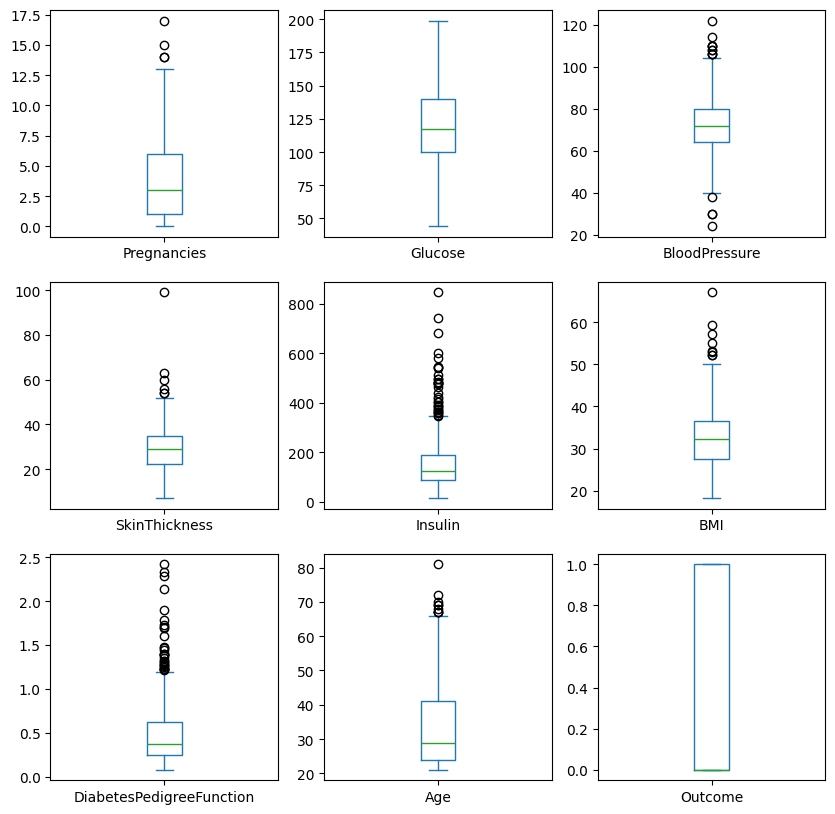

In [15]:
new_df.plot(
    kind='box',
    subplots=True,
    layout=(-1, 3),
    figsize=(10,10)
)
plt.show()

In [16]:
collums = [
  'Glucose',
  'BloodPressure',
  'SkinThickness',
  'BMI',
  'DiabetesPedigreeFunction',
  'Insulin',
  'Age'
]

for col in collums:
  Q1 = new_df[col].quantile(0.25)
  Q3 = new_df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  outliers = ((new_df[col] < lower) | (new_df[col] > upper)).sum()
  percent = outliers / len(new_df) * 100

  print(col, ":", round(percent,2), "%")

Glucose : 0.0 %
BloodPressure : 1.82 %
SkinThickness : 0.78 %
BMI : 1.04 %
DiabetesPedigreeFunction : 3.78 %
Insulin : 4.17 %
Age : 1.17 %


In [17]:
for col in collums:
  Q1 = new_df[col].quantile(0.25)
  Q3 = new_df[col].quantile(0.75)
  IQR = Q3 - Q1

  lower = Q1 - 1.5 * IQR
  upper = Q3 + 1.5 * IQR

  new_df[col] = new_df[col].clip(lower, upper)

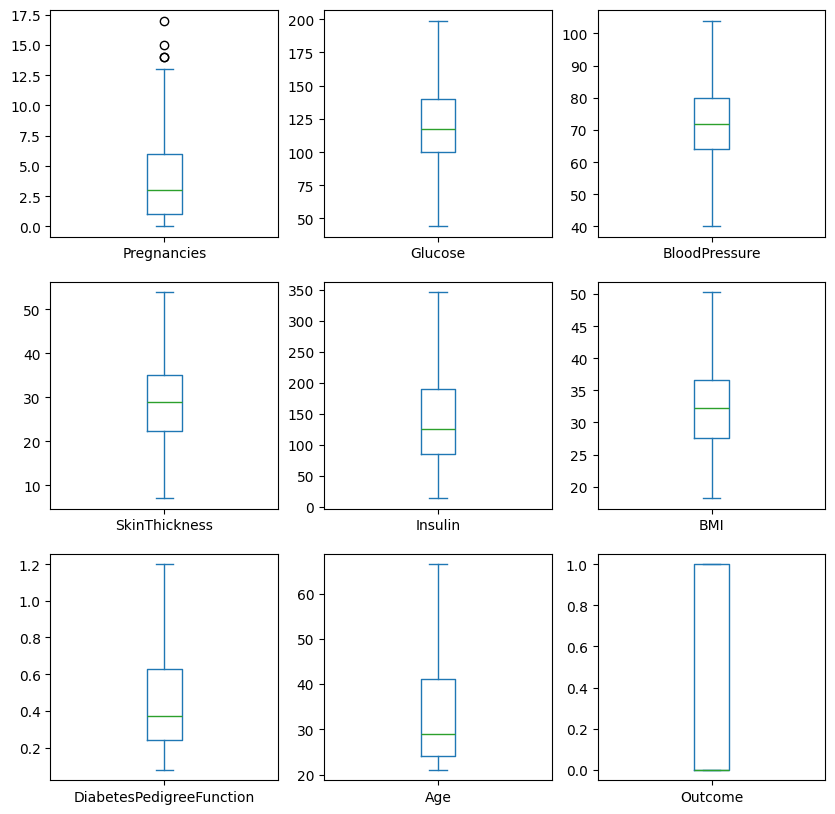

In [18]:
new_df.plot(
    kind='box',
    subplots=True,
    layout=(-1, 3),
    figsize=(10,10)
)
plt.show()

In [19]:
# check duplicate
new_df.duplicated().sum()

0

# **Data Transformation**

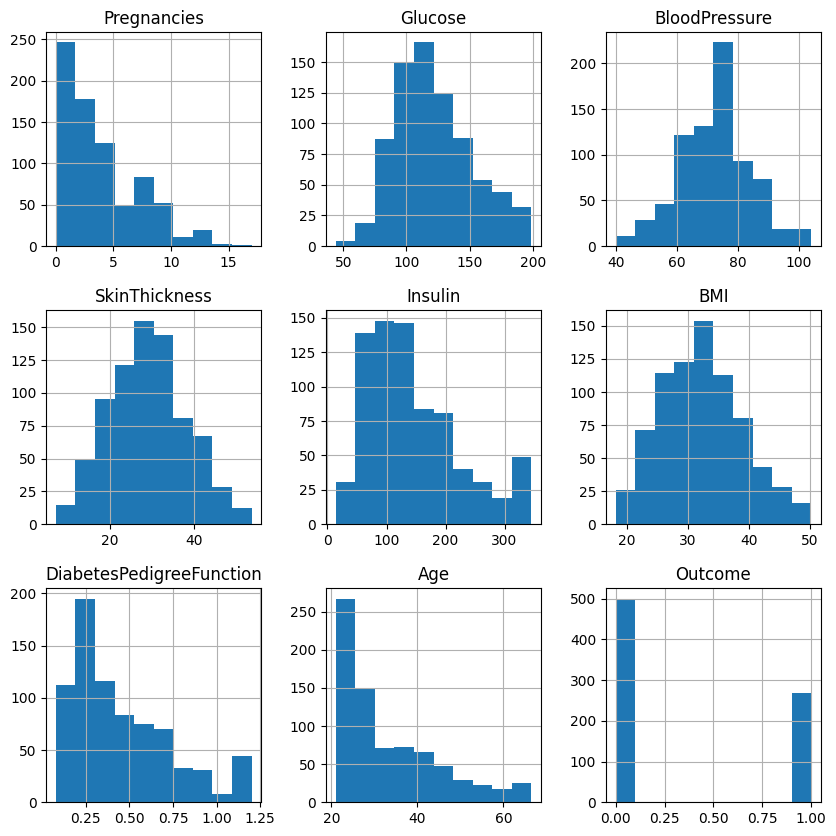

In [20]:
new_df.hist(figsize=(10, 10))
plt.show()

In [21]:
new_df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.656250,72.358073,28.985938,145.488281,32.393359,0.458914,33.199870,0.348958
std,3.369578,30.438286,11.697097,9.178356,80.480005,6.667471,0.285596,11.628404,0.476951
min,0.000000,44.000000,40.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,22.400000,85.950000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,29.000000,126.000000,32.300000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,35.000000,189.800000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,104.000000,53.900000,345.575000,50.250000,1.200000,66.500000,1.000000


### **1. Feature Selection**

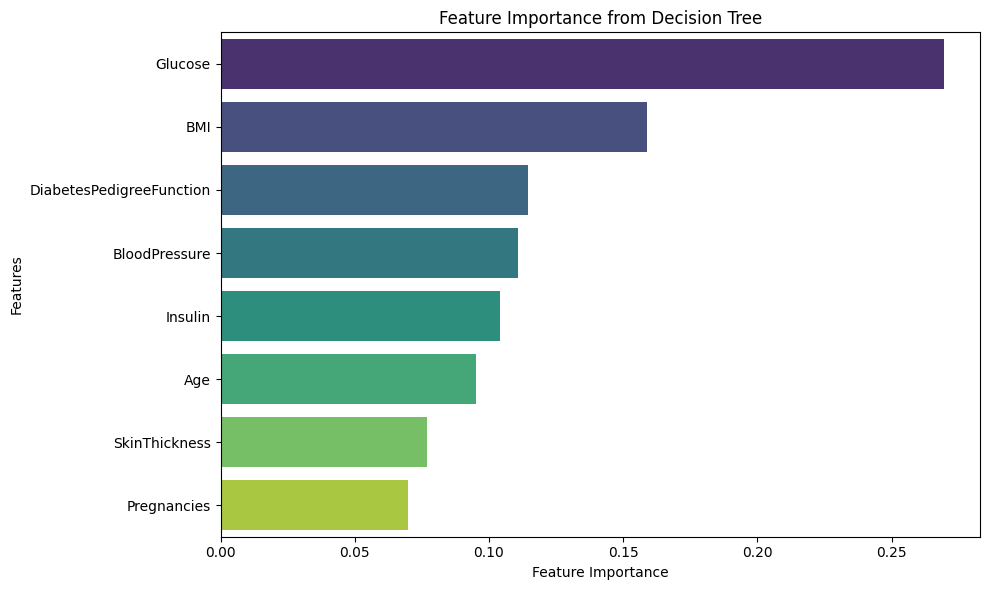


Feature Importances:
  Glucose: 0.2695
  BMI: 0.1588
  DiabetesPedigreeFunction: 0.1147
  BloodPressure: 0.1110
  Insulin: 0.1041
  Age: 0.0950
  SkinThickness: 0.0771
  Pregnancies: 0.0700


In [81]:
from sklearn.tree import DecisionTreeClassifier

x_temp = new_df.drop(columns=['Outcome'])
y_temp = new_df['Outcome']

temp_scaler = StandardScaler()
x_temp_scaled = temp_scaler.fit_transform(x_temp)

clf = DecisionTreeClassifier(criterion='gini', random_state=42)
clf.fit(x_temp_scaled, y_temp)

feature_importances = clf.feature_importances_
sorted_indices = np.argsort(feature_importances)[::-1]
sorted_features = x_temp.columns[sorted_indices]

plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importances[sorted_indices], y=sorted_features, hue=sorted_features, palette='viridis', legend=False)
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Feature Importance from Decision Tree')
plt.tight_layout()
plt.show()

print("\nFeature Importances:")
for feat, imp in zip(sorted_features, feature_importances[sorted_indices]):
    print(f"  {feat}: {imp:.4f}")

### **2. Data Transformation**

In [ ]:
transform_cols = [
    # 'Pregnancies',
    'Glucose',
    'BloodPressure',
    # 'SkinThickness',
    'Insulin',
    'BMI',
    'DiabetesPedigreeFunction',
    'Age'
]

x = new_df[transform_cols]
y = new_df['Outcome']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()

x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)


print(x_train_scaled.shape)
print(x_test_scaled.shape)

(614, 6)
(154, 6)


In [62]:
y_train.value_counts()

Outcome
0    400
1    214
Name: count, dtype: int64

### **3. Handling imbalance with oversampling**

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy=0.7,
    random_state=42
)
x_train_resampled, y_train_resampled = smote.fit_resample(x_train_scaled, y_train)

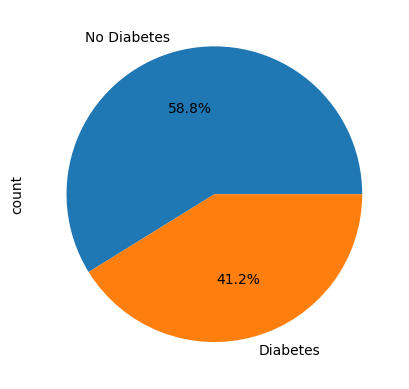

In [64]:
y_train_resampled.value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    labels=['No Diabetes', 'Diabetes'],
)

plt.show()

In [65]:
print(x_train_resampled.shape)
print(y_train_resampled.shape)
print(x_test_scaled.shape)
print(y_test.shape)

(680, 6)
(680,)
(154, 6)
(154,)


# **Logistic Regression**

In [66]:
from sklearn.linear_model import LogisticRegression

x_train_logistic, x_test_logistic = x_train_resampled.copy(), x_test_scaled.copy()
y_train_logistic, y_test_logistic = y_train_resampled.copy(), y_test.copy()

model_logistic = LogisticRegression(
    penalty='l2',
    C=0.1,
    max_iter=1000,
)

model_logistic.fit(x_train_logistic, y_train_logistic)
y_pred_logistic = model_logistic.predict(x_test_logistic)

print(f"Val Logistic Regression: {model_logistic.score(x_test_logistic, y_test_logistic):.4f}")
print(f"Train Logistic Regression: {model_logistic.score(x_train_logistic, y_train_logistic):.4f}")

Val Logistic Regression: 0.7143
Train Logistic Regression: 0.7662


In [67]:
from sklearn.metrics import classification_report

print("\nClassification of Logistic Regression Report:")
print(classification_report(y_test_logistic, y_pred_logistic))


Classification of Logistic Regression Report:
              precision    recall  f1-score   support

           0       0.77      0.79      0.78       100
           1       0.60      0.57      0.58        54

    accuracy                           0.71       154
   macro avg       0.69      0.68      0.68       154
weighted avg       0.71      0.71      0.71       154



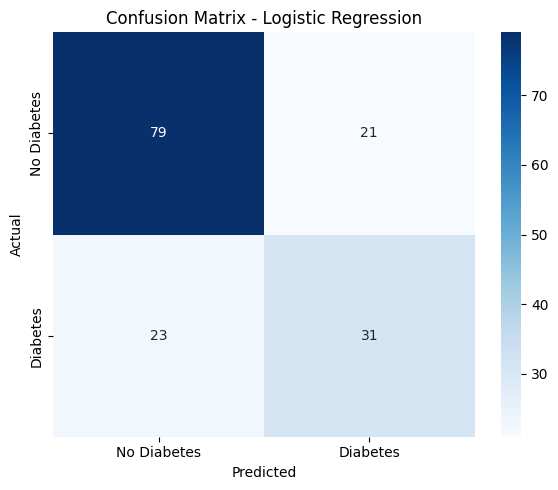

In [68]:
from sklearn.metrics import confusion_matrix

cm_lr = confusion_matrix(y_test_logistic, y_pred_logistic)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# **Random Forest**

In [69]:
from sklearn.ensemble import RandomForestClassifier

x_train_rf, x_test_rf = x_train_resampled.copy(), x_test_scaled.copy()
y_train_rf, y_test_rf = y_train_resampled.copy(), y_test.copy()

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42,
    min_samples_split=5,
    min_samples_leaf=2
)

rf_model.fit(x_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(x_test_rf)

print(f"Val Random Forest: {rf_model.score(x_test_rf, y_test_rf):.4f}")
print(f"Train Random Forest: {rf_model.score(x_train_rf, y_train_rf):.4f}")

Val Random Forest: 0.7468
Train Random Forest: 0.9706


In [70]:
print("\nClassification of Random Forest Report:")
print(classification_report(y_test_rf, y_pred_rf))


Classification of Random Forest Report:
              precision    recall  f1-score   support

           0       0.81      0.80      0.80       100
           1       0.64      0.65      0.64        54

    accuracy                           0.75       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



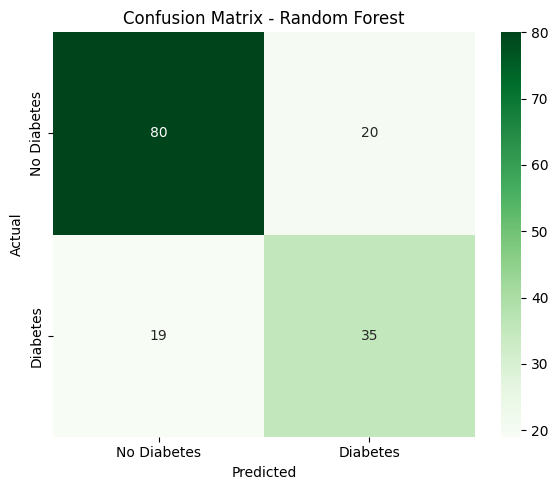

In [71]:
cm_rf = confusion_matrix(y_test_rf, y_pred_rf)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# **Navie Bayes**

In [72]:
from sklearn.naive_bayes import GaussianNB

x_train_nb, x_test_nb = x_train_resampled.copy(), x_test_scaled.copy()
y_train_nb, y_test_nb = y_train_resampled.copy(), y_test.copy()

nb_model = GaussianNB()

nb_model.fit(x_train_nb, y_train_nb)
y_pred_nb = nb_model.predict(x_test_nb)

print(f"Val Naive Bayes: {nb_model.score(x_test_nb, y_test_nb):.4f}")
print(f"Train Naive Bayes: {nb_model.score(x_train_nb, y_train_nb):.4f}")

Val Naive Bayes: 0.7208
Train Naive Bayes: 0.7559


In [73]:
print("\nClassification of Naive Bayes Report:")
print(classification_report(y_test_nb, y_pred_nb))


Classification of Naive Bayes Report:
              precision    recall  f1-score   support

           0       0.79      0.77      0.78       100
           1       0.60      0.63      0.61        54

    accuracy                           0.72       154
   macro avg       0.70      0.70      0.70       154
weighted avg       0.72      0.72      0.72       154



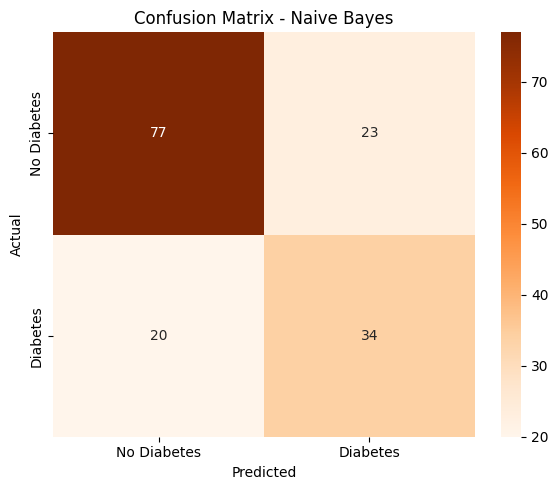

In [74]:
cm_nb = confusion_matrix(y_test_nb, y_pred_nb)
plt.figure(figsize=(6, 5))
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No Diabetes', 'Diabetes'],
            yticklabels=['No Diabetes', 'Diabetes'])
plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# **ROC-AUC Curves**

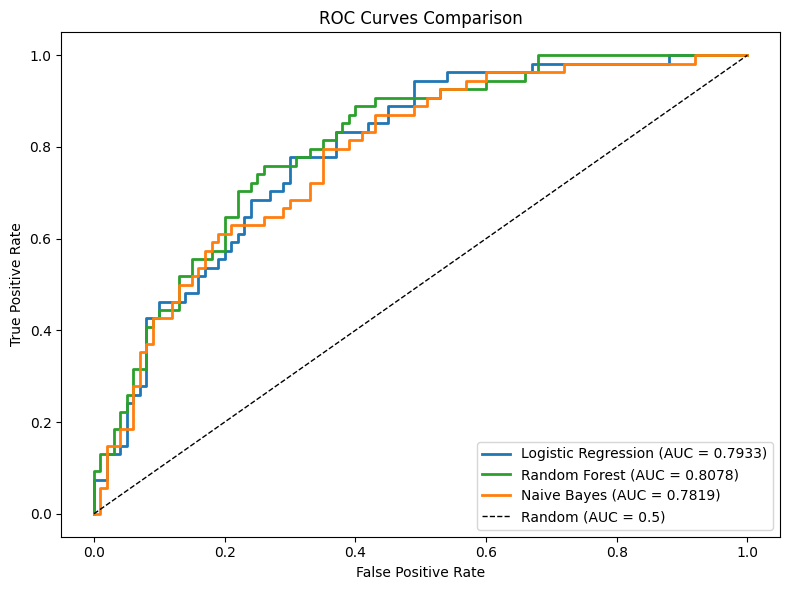

In [75]:
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(8, 6))

models = {
    'Logistic Regression': (model_logistic, x_test_logistic, y_test_logistic),
    'Random Forest': (rf_model, x_test_rf, y_test_rf),
    'Naive Bayes': (nb_model, x_test_nb, y_test_nb),
}
colors = ['#1f77b4', '#2ca02c', '#ff7f0e']

for (name, (model, x_ts, y_ts)), color in zip(models.items(), colors):
    y_proba = model.predict_proba(x_ts)[:, 1]
    fpr, tpr, _ = roc_curve(y_ts, y_proba)
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC = {roc_auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curves Comparison')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

# **Cross-Validation (5-Fold)**

In [76]:
from sklearn.model_selection import cross_val_score

x_cv = np.vstack([x_train_resampled, x_test_scaled])
y_cv = np.concatenate([y_train_resampled, y_test])

cv_models = {
    'Logistic Regression': LogisticRegression(penalty='l2', C=0.1, max_iter=1000),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, min_samples_split=5, min_samples_leaf=2),
    'Naive Bayes': GaussianNB(),
}

print(f"{'Model':<25} {'Mean Accuracy':<18} {'Std':<10}")
print("-" * 53)
for name, model in cv_models.items():
    scores = cross_val_score(model, x_cv, y_cv, cv=5, scoring='accuracy')
    print(f"{name:<25} {scores.mean():.4f}            {scores.std():.4f}")

Model                     Mean Accuracy      Std       
-----------------------------------------------------
Logistic Regression       0.7541            0.0305
Random Forest             0.7661            0.0308
Naive Bayes               0.7458            0.0240


# **Model Comparison**

                     Accuracy  Precision  Recall  F1-Score  ROC-AUC
Model                                                              
Logistic Regression    0.7143     0.5962  0.5741    0.5849   0.7933
Random Forest          0.7468     0.6364  0.6481    0.6422   0.8078
Naive Bayes            0.7208     0.5965  0.6296    0.6126   0.7819


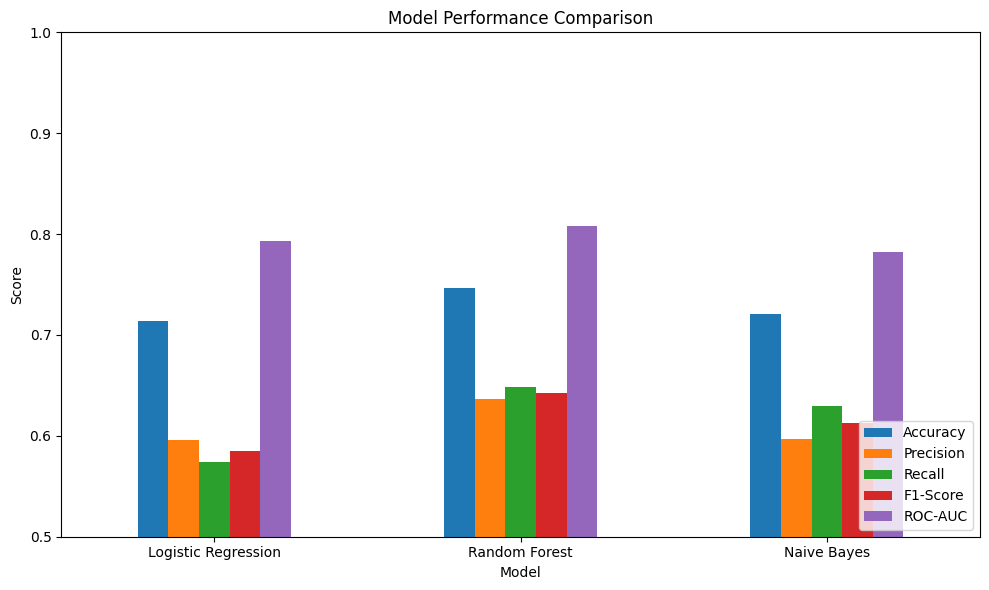

In [77]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

results = []
model_preds = {
    'Logistic Regression': (model_logistic, x_test_logistic, y_test_logistic, y_pred_logistic),
    'Random Forest': (rf_model, x_test_rf, y_test_rf, y_pred_rf),
    'Naive Bayes': (nb_model, x_test_nb, y_test_nb, y_pred_nb),
}

for name, (model, x_ts, y_ts, y_pred) in model_preds.items():
    y_proba = model.predict_proba(x_ts)[:, 1]
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_ts, y_pred),
        'Precision': precision_score(y_ts, y_pred),
        'Recall': recall_score(y_ts, y_pred),
        'F1-Score': f1_score(y_ts, y_pred),
        'ROC-AUC': roc_auc_score(y_ts, y_proba),
    })

comparison_df = pd.DataFrame(results).set_index('Model')
comparison_df = comparison_df.round(4)

print(comparison_df.to_string())

comparison_df.plot(kind='bar', figsize=(10, 6), rot=0)
plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.ylim(0.5, 1.0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# **Test**

In [84]:
# pregnancies = 6
glucoso = 180
blood_pressure = 70
# skin_thickness = 25
insulin = 94
bmi = 40
diabetes_pedigree_function = 0.5
age = 50

# new_patient = np.array([[pregnancies, glucoso, blood_pressure, skin_thickness, insulin, bmi, diabetes_pedigree_function, age]])
new_patient = pd.DataFrame([[glucoso, blood_pressure, insulin, bmi, diabetes_pedigree_function, age]], columns=transform_cols)

new_patient_scaled = scaler.transform(new_patient)

lr_prediction = model_logistic.predict(new_patient_scaled)
rf_prediction = rf_model.predict(new_patient_scaled)
nb_prediction = nb_model.predict(new_patient_scaled)

print("Logistic Regression Prediction:", lr_prediction)
print("Random Forest Prediction:", rf_prediction)
print("Naive Bayes Prediction:", nb_prediction)

Logistic Regression Prediction: [1]
Random Forest Prediction: [1]
Naive Bayes Prediction: [1]


In [80]:
# save model and scaler

import joblib

ver = 2

joblib.dump(model_logistic, f'./model/{ver}/model_logistic.pkl')
joblib.dump(rf_model, f'./model/{ver}/rf_model.pkl')
joblib.dump(nb_model, f'./model/{ver}/nb_model.pkl')
joblib.dump(scaler, f'./model/{ver}/scaler.pkl')

['./model/2/scaler.pkl']